# Trust-Region Methods
### MECH 559 - Systems Optimization - L06
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

Instead of picking a direction and then searching for a good step length (line search), trust-region methods fix a region of trusted radius $\Delta_k$ and solve a *constrained* quadratic subproblem inside it at every iteration. This notebook builds that subproblem solver and the full adaptive-radius algorithm from scratch, and shows why it succeeds where plain Newton's method (from the previous notebook) can fail.

## Learning objectives

By the end, students should be able to:

1. Solve the trust-region subproblem $\min_{d} f_k+\nabla f_k^{\mathrm T}d+\tfrac12 d^{\mathrm T}H_kd$ s.t. $\|d\|_2\le\Delta_k$ via the $(H_k+\mu_kI)^{-1}$ characterization.
2. Implement the standard adaptive trust-region loop (predicted-vs-actual reduction ratio $\rho_k$, radius update).
3. Reproduce the saddle-point failure of plain Newton's method and show trust-region naturally avoids it.
4. Visualize how the trust-region radius grows and shrinks as the algorithm proceeds.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "bad": "0.5"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Solving the trust-region subproblem

If the unconstrained minimizer of the quadratic model, $-H_k^{-1}\nabla f_k$, already lies inside the trust region (and $H_k\succ0$), that's the solution: the constraint is *inactive*. Otherwise the constraint is *active* and the solution has the form $d_k(\mu_k)=-(H_k+\mu_kI)^{-1}\nabla f_k$ for some $\mu_k>0$ chosen so that $\|d_k(\mu_k)\|_2=\Delta_k$ - found here by bisection on $\mu$.

In [3]:
def solve_trust_region_subproblem(g, H, Delta, max_bisect=100):
    n = len(g)
    # Try the unconstrained (inactive-constraint) minimizer first.
    eigvals = np.linalg.eigvalsh(H)
    if np.all(eigvals > 0):
        d0 = np.linalg.solve(H, -g)
        if np.linalg.norm(d0) <= Delta:
            return d0, "inactive"
    # Constraint is active: bisect on mu>0 so that ||d(mu)|| = Delta.
    def dnorm(mu):
        return np.linalg.norm(np.linalg.solve(H + mu*np.eye(n), -g))
    lo, hi = 0.0, 1.0
    while dnorm(hi) > Delta:
        hi *= 2.0
        if hi > 1e10:
            break
    for _ in range(max_bisect):
        mid = 0.5*(lo + hi)
        if dnorm(mid) > Delta:
            lo = mid
        else:
            hi = mid
    mu = 0.5*(lo + hi)
    return np.linalg.solve(H + mu*np.eye(n), -g), "active"

# Sanity check: for a positive-definite H and a large enough Delta, we should recover the plain Newton step.
H_test = np.array([[4.0, 1.0], [1.0, 3.0]])
g_test = np.array([1.0, -2.0])
d_newton = np.linalg.solve(H_test, -g_test)
d_tr, status = solve_trust_region_subproblem(g_test, H_test, Delta=10.0)
print(f"Newton step: {np.round(d_newton,4)}, trust-region step (large Delta): {np.round(d_tr,4)}  ({status})")

d_tr_small, status_small = solve_trust_region_subproblem(g_test, H_test, Delta=0.1)
print(f"trust-region step (Delta=0.1): {np.round(d_tr_small,4)}, ||d||={np.linalg.norm(d_tr_small):.4f}  ({status_small})")

Newton step: [-0.4545  0.8182], trust-region step (large Delta): [-0.4545  0.8182]  (inactive)
trust-region step (Delta=0.1): [-0.0454  0.0891], ||d||=0.1000  (active)


---
## 2. The full adaptive trust-region algorithm

Standard loop: solve the subproblem, compute the ratio of actual to predicted reduction $\rho_k$, accept the step only if $\rho_k$ is not too small, and grow/shrink $\Delta_k$ based on how well the quadratic model predicted the actual improvement.

In [4]:
def trust_region(grad_func, hess_func, func, x0, Delta0=1.0, Delta_max=5.0, eta=0.1, n_iter=60, tol=1e-8):
    x = np.array(x0, dtype=float)
    Delta = Delta0
    traj = [x.copy()]
    deltas = [Delta]
    for k in range(n_iter):
        g = grad_func(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_func(x)
        d, status = solve_trust_region_subproblem(g, H, Delta)
        predicted = -(g @ d + 0.5 * d @ H @ d)
        actual = func(x) - func(x + d)
        rho = actual / predicted if predicted > 1e-14 else -1.0
        if rho < 0.25:
            Delta = 0.25 * Delta
        elif rho > 0.75 and np.linalg.norm(d) >= 0.99 * Delta:
            Delta = min(2 * Delta, Delta_max)
        if rho > eta:
            x = x + d
        traj.append(x.copy())
        deltas.append(Delta)
    return np.array(traj), deltas

print("trust_region() ready.")

trust_region() ready.


---
## 3. Trust region vs. plain Newton on the saddle-point example

Reusing the previous notebook's function, $f(x_1,x_2)=\tfrac13x_1^3+x_1x_2+\tfrac12x_2^2+2x_2-\tfrac23$, which has a real minimizer at $(2,-4)$ and a saddle at $(-1,-1)$: unmodified Newton's method converged to the *saddle* from $x_0=(0,0)$. Trust region, with no Hessian modification at all, should not.

> **Predict:** why might solving a *constrained* quadratic subproblem naturally avoid being fooled by an indefinite Hessian, even without explicitly regularizing it?

plain Newton converges to:  [-1. -1.]  (5 iterations)  <- the SADDLE
trust region converges to: [ 2. -4.]  (6 iterations)  <- the true minimizer


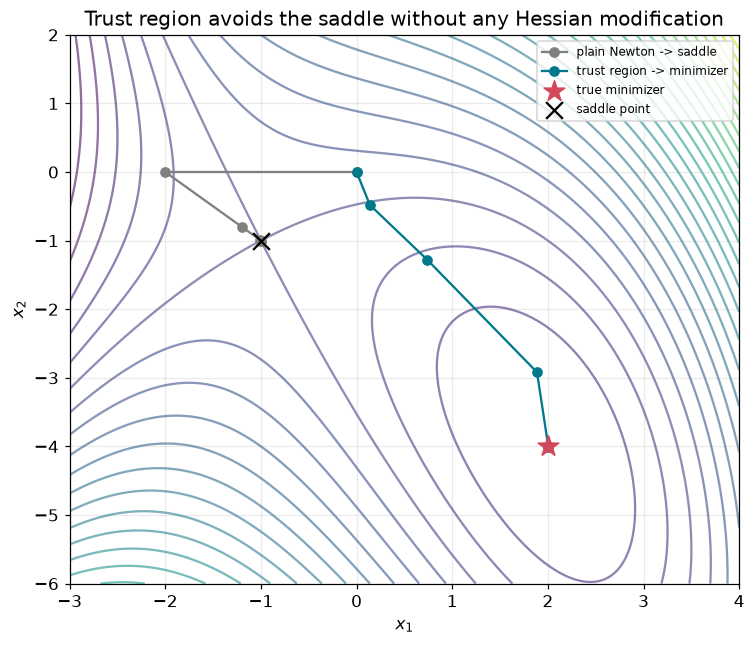

In [5]:
def f_cubic(x):
    x1, x2 = x
    return (1/3)*x1**3 + x1*x2 + 0.5*x2**2 + 2*x2 - 2/3

def grad_cubic(x):
    x1, x2 = x
    return np.array([x1**2 + x2, x1 + x2 + 2])

def hess_cubic(x):
    x1, x2 = x
    return np.array([[2*x1, 1.0], [1.0, 1.0]])

def newton_raw(x0, n_iter=15, tol=1e-8):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for _ in range(n_iter):
        g = grad_cubic(x)
        if np.linalg.norm(g) < tol:
            break
        d = np.linalg.solve(hess_cubic(x), -g)
        x = x + d
        traj.append(x.copy())
    return np.array(traj)

x0 = [0.0, 0.0]
traj_newton = newton_raw(x0)
traj_tr, deltas_tr = trust_region(grad_cubic, hess_cubic, f_cubic, x0, Delta0=0.5, Delta_max=3.0)

print(f"plain Newton converges to:  {np.round(traj_newton[-1],4)}  ({len(traj_newton)-1} iterations)  <- the SADDLE")
print(f"trust region converges to: {np.round(traj_tr[-1],4)}  ({len(traj_tr)-1} iterations)  <- the true minimizer")

x1g, x2g = np.meshgrid(np.linspace(-3, 4, 200), np.linspace(-6, 2, 200))
Z = (1/3)*x1g**3 + x1g*x2g + 0.5*x2g**2 + 2*x2g - 2/3
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(x1g, x2g, Z, levels=40, cmap="viridis", alpha=0.6)
ax.plot(traj_newton[:, 0], traj_newton[:, 1], "-o", color=COLORS["bad"], label="plain Newton -> saddle")
ax.plot(traj_tr[:, 0], traj_tr[:, 1], "-o", color=COLORS["boundary"], label="trust region -> minimizer")
ax.scatter([2], [-4], marker="*", s=200, color=COLORS["optimum"], zorder=5, label="true minimizer")
ax.scatter([-1], [-1], marker="x", s=120, color="black", zorder=5, label="saddle point")
ax.legend(fontsize=8)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Trust region avoids the saddle without any Hessian modification")
plt.tight_layout()
plt.show()

---
## 4. Watching the trust-region radius adapt

The radius shrinks whenever the quadratic model overpromises ($\rho_k$ small) and grows when the model is trustworthy and the step used the full radius.

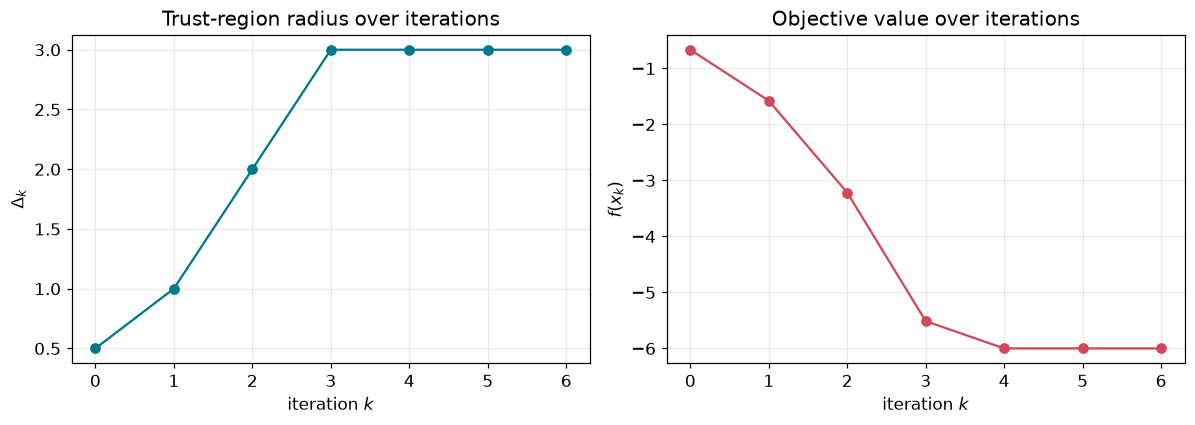

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(deltas_tr, "-o", color=COLORS["boundary"])
axes[0].set(xlabel="iteration $k$", ylabel=r"$\Delta_k$", title="Trust-region radius over iterations")

f_vals = [f_cubic(x) for x in traj_tr]
axes[1].plot(f_vals, "-o", color=COLORS["optimum"])
axes[1].set(xlabel="iteration $k$", ylabel="$f(x_k)$", title="Objective value over iterations")
plt.tight_layout()
plt.show()

---
## 5. Interactive: initial radius and growth cap

Try starting with a very small or very large $\Delta_0$ and see whether trust region still finds the minimizer (rather than the saddle) from the same starting point.

In [7]:
def tr_demo(Delta0=0.5, Delta_max=3.0, x0_1=0.0, x0_2=0.0):
    traj, deltas = trust_region(grad_cubic, hess_cubic, f_cubic, [x0_1, x0_2], Delta0=Delta0, Delta_max=Delta_max)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.contour(x1g, x2g, Z, levels=40, cmap="viridis", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "-o", color=COLORS["boundary"])
    ax.scatter([2], [-4], marker="*", s=200, color=COLORS["optimum"], zorder=5, label="minimizer")
    ax.scatter([-1], [-1], marker="x", s=120, color="black", zorder=5, label="saddle")
    ax.legend(fontsize=8)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=f"final: {np.round(traj[-1],3)} in {len(traj)-1} iters")
    plt.tight_layout()
    plt.show()

if WIDGETS_AVAILABLE:
    display(widgets.interactive(tr_demo,
                                 Delta0=widgets.FloatLogSlider(value=0.5, base=10, min=-2, max=1, step=0.1),
                                 Delta_max=widgets.FloatSlider(value=3.0, min=0.5, max=10.0, step=0.5),
                                 x0_1=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1),
                                 x0_2=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1)))
else:
    print("ipywidgets is not installed; running the default case.")
    tr_demo()

interactive(children=(FloatLogSlider(value=0.5, description='Delta0', max=1.0, min=-2.0), FloatSlider(value=3.…

---
## 6. Visualizing the trust region and its local model together

This is the same idea the lecture slides now show directly: the true objective's contours, the *local quadratic model's* contours, and the trust-region disk, all in one picture, updated every iteration. Where the two sets of contours line up, the model is trustworthy; where they diverge, it isn't - and that is exactly what drives $\rho_k$ and the radius update.

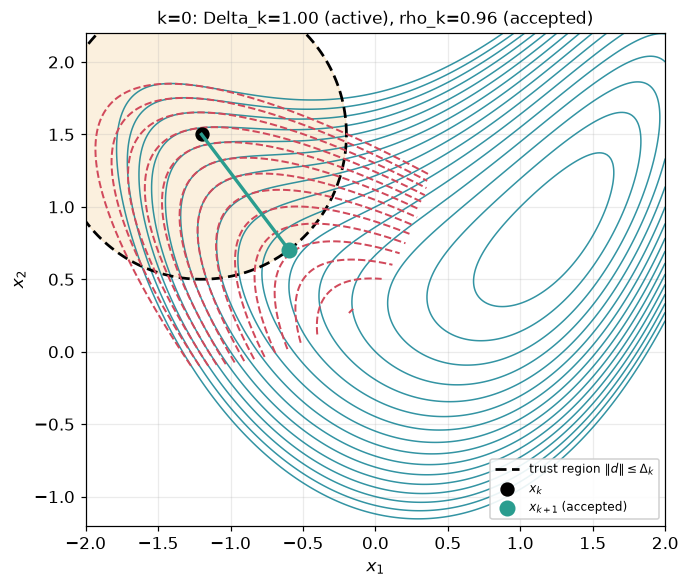

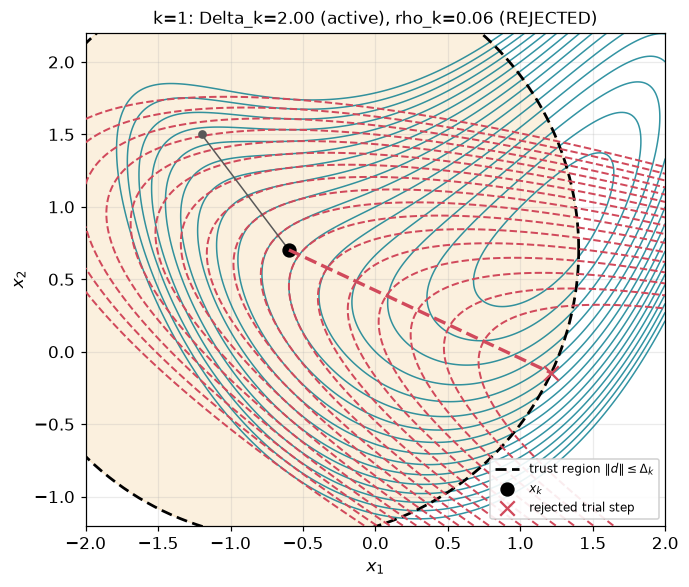

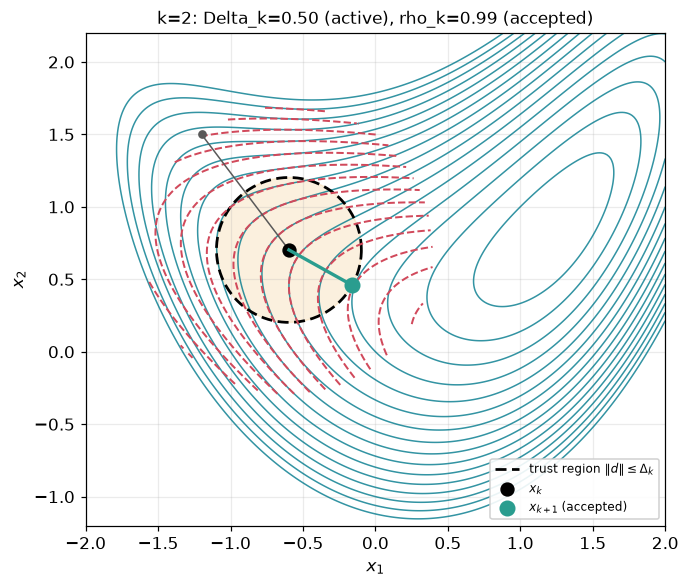

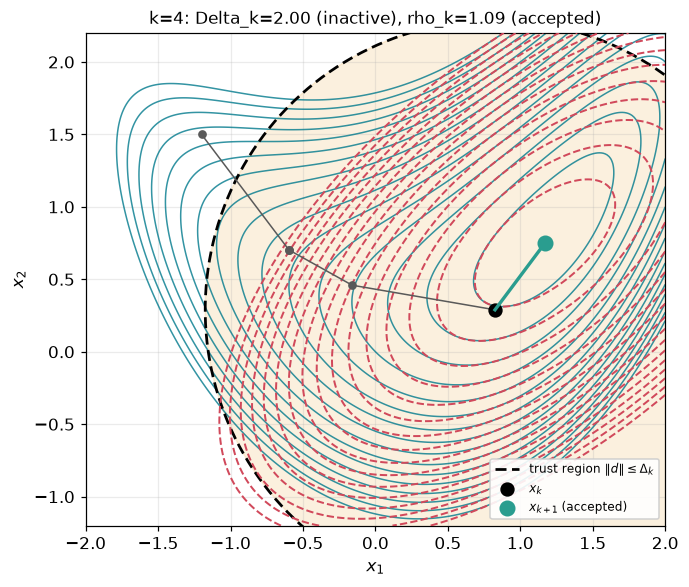

In [8]:
def f_smooth(x):
    x1, x2 = x
    return (1 - x1)**2 + (1 - x2)**2 + 0.5*(-x1**2 + 2*x2)**2

def _fd_grad(func, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        s = np.zeros_like(x); s[i] = h
        g[i] = (func(x + s) - func(x - s)) / (2*h)
    return g

def _fd_hess(func, x, h=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si = np.zeros(n); si[i] = h
            sj = np.zeros(n); sj[j] = h
            H[i, j] = (func(x+si+sj) - func(x+si-sj) - func(x-si+sj) + func(x-si-sj)) / (4*h*h)
    return H

grad_smooth = lambda x: _fd_grad(f_smooth, x)
hess_smooth = lambda x: _fd_hess(f_smooth, x)

def quad_model(x, g, H, X1, X2):
    D1, D2 = X1 - x[0], X2 - x[1]
    return f_smooth(x) + g[0]*D1 + g[1]*D2 + 0.5*(H[0,0]*D1**2 + 2*H[0,1]*D1*D2 + H[1,1]*D2**2)

def trust_region_history(x0, Delta0, Delta_max, eta=0.1, n_iter=8, tol=1e-8):
    x = np.array(x0, dtype=float)
    Delta = Delta0
    hist = []
    for k in range(n_iter):
        g = grad_smooth(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_smooth(x)
        d, status = solve_trust_region_subproblem(g, H, Delta)
        predicted = -(g @ d + 0.5 * d @ H @ d)
        actual = f_smooth(x) - f_smooth(x + d)
        rho = actual / predicted if predicted > 1e-14 else -1.0
        accepted = rho > eta
        hist.append(dict(k=k, x=x.copy(), Delta=Delta, g=g.copy(), H=H.copy(),
                          status=status, rho=rho, accepted=accepted, x_trial=x + d))
        if rho < 0.25:
            Delta = 0.25 * Delta
        elif rho > 0.75 and np.linalg.norm(d) >= 0.99 * Delta:
            Delta = min(2 * Delta, Delta_max)
        if accepted:
            x = x + d
    return hist

hist_smooth = trust_region_history([-1.2, 1.5], Delta0=1.0, Delta_max=3.0)
path_smooth = [h["x"] for h in hist_smooth]

x1_lim, x2_lim = (-2.0, 2.0), (-1.2, 2.2)
x1g_s, x2g_s = np.meshgrid(np.linspace(*x1_lim, 300), np.linspace(*x2_lim, 300))
Zg_s = (1 - x1g_s)**2 + (1 - x2g_s)**2 + 0.5*(-x1g_s**2 + 2*x2g_s)**2
levels_s = np.linspace(0, 8, 17)

def plot_tr_snapshot(idx):
    h = hist_smooth[idx]
    x, Delta, g, H = h["x"], h["Delta"], h["g"], h["H"]
    status, rho, accepted, x_trial = h["status"], h["rho"], h["accepted"], h["x_trial"]

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    ax.contour(x1g_s, x2g_s, Zg_s, levels=levels_s, colors=COLORS["boundary"], linewidths=1.0, alpha=0.8)

    theta = np.linspace(0, 2*np.pi, 200)
    ax.fill(x[0] + Delta*np.cos(theta), x[1] + Delta*np.sin(theta), color=COLORS["accent"], alpha=0.18, zorder=1)
    ax.plot(x[0] + Delta*np.cos(theta), x[1] + Delta*np.sin(theta), color="black", lw=1.8, ls=(0, (4, 2)), zorder=2,
            label=r"trust region $\|d\|\leq\Delta_k$")

    mask_radius = max(1.6*Delta, 1.0)
    Mg = quad_model(x, g, H, x1g_s, x2g_s)
    dist = np.sqrt((x1g_s - x[0])**2 + (x2g_s - x[1])**2)
    ax.contour(x1g_s, x2g_s, np.where(dist <= mask_radius, Mg, np.nan), levels=levels_s,
               colors=COLORS["optimum"], linewidths=1.3, linestyles="dashed", zorder=3)

    for prev in path_smooth[:idx]:
        ax.scatter(*prev, color="0.35", s=22, zorder=4)
    ax.plot([p[0] for p in path_smooth[:idx+1]], [p[1] for p in path_smooth[:idx+1]], color="0.35", lw=1.0, zorder=3)
    ax.scatter(*x, color="black", s=70, zorder=5, label="$x_k$")

    step_color = "#2A9D8F" if accepted else COLORS["optimum"]
    ax.plot([x[0], x_trial[0]], [x[1], x_trial[1]], color=step_color, lw=2.2,
            ls=("-" if accepted else "--"), zorder=5)
    ax.scatter(*x_trial, color=step_color, s=90, zorder=6, marker=("o" if accepted else "x"),
               label=("$x_{k+1}$ (accepted)" if accepted else "rejected trial step"))

    ax.set_xlim(*x1_lim); ax.set_ylim(*x2_lim); ax.set_aspect("equal")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    verdict = "accepted" if accepted else "REJECTED"
    ax.set_title(f"k={h['k']}: Delta_k={Delta:.2f} ({status}), rho_k={rho:.2f} ({verdict})", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()

for idx in [0, 1, 2, 4]:
    plot_tr_snapshot(idx)

---
## Takeaways

1. The trust-region subproblem's solution is always characterized by $d_k(\mu_k)=-(H_k+\mu_kI)^{-1}\nabla f_k$ for some $\mu_k\ge0$ - $\mu_k=0$ when the unconstrained quadratic minimizer already fits inside the region, $\mu_k>0$ (found by bisection here) otherwise.
2. Because $\mu_k$ can be driven up until $H_k+\mu_kI$ is effectively positive definite, trust region handles indefinite Hessians *automatically*, without a separate modification step.
3. On the saddle-point example, trust region converges to the genuine minimizer from the same starting point where plain Newton converges to the saddle.
4. The radius $\Delta_k$ adapts on its own: it shrinks after a disappointing step and grows after a trustworthy one, which is what lets the method be both cautious near difficult regions and fast once it's in a well-behaved one.

## Optional exercises

1. Compare the bisection-based subproblem solver's step to the closed-form dogleg approximation (linear combination of the steepest-descent and Newton directions) on a couple of test points - how different are they?
2. Start trust region very close to the saddle point itself, e.g. $x_0=(-1.01,-1.0)$. Does it still escape? Why or why not?
3. Modify `trust_region` to record and plot $\rho_k$ at each iteration alongside $\Delta_k$ - confirm that every radius shrink corresponds to a small (or negative) $\rho_k$.